# WINTER Bench Sensor PTC Analysis

### 1. Quick PTC: 2 pts per exposure time

This follows the general Janesick approach of having two exposures at each exposure time and using them to remove the FPN from the PTC.

In [186]:
# Import modules

import os
from pathlib import Path
from glob import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from analysis.utils.utils import plot_image


In [187]:
import os, json
from glob import glob

import numpy as np
import numpy.typing as npt
from typing import Any
from pathlib import Path
import pandas as pd
from astropy.io import fits
import re
from datetime import datetime, timezone



def parse_bench_filename(filename: str) -> dict:
    """
    Parse a bench camera FITS filename into structured metadata.
    """

    name = Path(filename).name
    stem = name.replace(".fits", "")

    pattern = re.compile(
        r"""
        (?P<sensor>\w+)_                                   # sensor
        (?P<date>\d{8})_                                  # YYYYMMDD
        texp_(?P<exptime>[\d.]+)_                          # exposure time (s)
        (?P<frame_type>dark|light)_                        # frame type
        (?P<pd_current>[\d.]+)_nA_                         # photodiode current (nA)
        (?P<temperature>-?[\d.]+)C_                        # temperature (C)
        (?P<filter>\d+)nm_                                 # filter wavelength (nm)
        (?P<timestamp>\d{8}-\d{6}-\d{3})                   # full timestamp
        """,
        re.VERBOSE
    )

    m = pattern.match(stem)
    if not m:
        raise ValueError(f"Filename does not match expected format: {filename}")

    # Parse date (YYYYMMDD)
    date = datetime.strptime(m.group("date"), "%Y%m%d").date()

    # Parse UTC timestamp: YYYYMMDD-HHMMSS-ms
    ts = m.group("timestamp")
    timestamp = datetime.strptime(ts, "%Y%m%d-%H%M%S-%f").replace(tzinfo=timezone.utc)

    return {
        "sensor": m.group("sensor"),
        "date": date,
        "time": timestamp,
        "exposure_time": float(m.group("exptime")),
        "frame_type": m.group("frame_type"),
        "photodiode_current_nA": float(m.group("pd_current")),
        "temperature": float(m.group("temperature")),
        "filter": int(m.group("filter")),
    }
'''
def build_database(dirs_to_load) -> pd.DataFrame:
    data_records = []

    for data_dir in dirs_to_load:
        try:
            run_info_path = os.path.join(data_dir, "run_info.json")
            with open(run_info_path, "r") as f:
                run_info = json.load(f)

            frame_type = run_info["frame_type"].lower()
            print(f"Loading {frame_type} frames from {data_dir}")

            files = sorted(glob(os.path.join(data_dir, "std_stream_*.fits")))
            print(f"found {len(files)} files in {data_dir}")

            for filepath in files:
                filename = os.path.basename(filepath)
                exptime_s = get_exptime_from_filename(filename)

                data, n_images, header = read_fits_stack(filepath)

                data_records.append({
                    "filename": filename,
                    "filepath": str(filepath),
                    "frame_type": frame_type,
                    "exposure_time": exptime_s,
                    "n_images": n_images,
                    "header": header,
                    "data": data,
                })

        except Exception as e:
            print(f"could not load data from {data_dir}: {e}")

    df = pd.DataFrame(data_records)
    return df.sort_values(["frame_type", "exposure_time"]).reset_index(drop=True)
'''
def split_data_into_channels(
        self,
        data: npt.NDArray[Any],
    ) -> npt.NDArray[Any]:
        """
        Splits a 2D array into 8 channels by sampling rows and columns
        at regular offsets.

        Each of the 8 channels is extracted by:
        1. Choosing a row offset (j::2), where j = 1 for the first four channels
            (channels 0..3) and j = 0 for the latter four (channels 4..7).
        2. Choosing a column offset ((3 - i) % 4::4), where i is the channel index.

        Parameters
        ----------
        data : numpy.typing.NDArray[Any]
            2D array of shape (height, width). Must be evenly divisible so that
            height % 2 == 0 and width % 4 == 0.

        Returns
        -------
        channels_3d : numpy.typing.NDArray[Any]
            3D array of shape (8, height//2, width//4). The first dimension indexes
            the 8 channels, and the remaining two dimensions are the downsampled rows
            and columns for each channel.
        """
        height, width = data.shape

        # Number of channels to produce
        channels = 8

        # Prepare the output array
        data_8ch = np.zeros((channels, height // 2, width // 4), dtype=data.dtype)

        # Fill each of the 8 channels
        for i in range(channels):
            # Row offset (use j=1 for channels 0..3, j=0 for channels 4..7)
            j = 1 if (3 - i) >= 0 else 0
            # Column offset is (3 - i) % 4
            data_8ch[i] = data[j::2, (3 - i) % 4 :: 4]

        return data_8ch

def build_database(dir_to_load, channel = 1) -> pd.DataFrame:
    data_records = []

    data_dir = dir_to_load

    files = sorted(glob(os.path.join(data_dir, "*.fits")))
    print(f"found {len(files)} files in {data_dir}")

    for filepath in files:
        try:
            filename = os.path.basename(filepath)

            image_info = parse_bench_filename(filename)
            frame_type = image_info["frame_type"]
            exptime_s = image_info["exposure_time"]

            # load the fits data

            with fits.open(filepath) as hdul:
                data = hdul[0].data
                header = hdul[0].header
            
            # split into channels
            data_8ch = split_data_into_channels(None, data)

            data = data_8ch[channel]

            data_records.append({
                "filename": filename,
                "filepath": str(filepath),
                "frame_type": frame_type,
                "exposure_time": exptime_s,
                "n_images": 1,
                "header": header,
                "data": data,
            })

        except Exception as e:
            print(f"could not load data from {data_dir}: {e}")

    df = pd.DataFrame(data_records)
    return df.sort_values(["frame_type", "exposure_time"]).reset_index(drop=True)



def stack_database(
    df: pd.DataFrame,
    group_cols=("frame_type", "exposure_time"),
    sort_cols=("time", "filename"),
    data_col="data",
) -> pd.DataFrame:
    """
    Convert a per-file dataframe (each row has a 2D image) into a per-(frame_type, exposure_time)
    dataframe where each row has a 3D cube in `data` with shape (n_frames, ny, nx).

    Assumes df[data_col] entries are 2D arrays of identical shape within each group.
    """
    df = df.copy()

    # sort within each group so stack order is deterministic
    # (only keep sort columns that actually exist)
    sort_cols_present = [c for c in sort_cols if c in df.columns]
    if sort_cols_present:
        df = df.sort_values(list(group_cols) + sort_cols_present)

    rows = []
    for keys, g in df.groupby(list(group_cols), sort=False):
        # g is the per-file rows for one exposure + type
        imgs = list(g[data_col].values)

        # sanity: require 2D arrays
        for k, im in enumerate(imgs):
            if not isinstance(im, np.ndarray) or im.ndim != 2:
                raise ValueError(
                    f"Expected 2D ndarray in column '{data_col}', got {type(im)} "
                    f"with shape {getattr(im, 'shape', None)} in group {keys}, index {g.index[k]}"
                )

        cube = np.stack(imgs, axis=0)  # (n, y, x)

        # choose a representative row's metadata
        rep = g.iloc[0].to_dict()

        rep[data_col] = cube
        rep["n_images"] = cube.shape[0]

        # store filenames used (helpful for debugging)
        rep["filenames"] = list(g["filename"].values) if "filename" in g.columns else None
        rep["filepaths"] = list(g["filepath"].values) if "filepath" in g.columns else None

        # If you want per-group mean time:
        if "time" in g.columns:
            rep["time"] = g["time"].min()

        rows.append(rep)

    out = pd.DataFrame(rows)

    # keep your downstream assumptions: sort by frame_type, exposure_time, filename
    sort_out = [c for c in ["frame_type", "exposure_time", "filename"] if c in out.columns]
    if sort_out:
        out = out.sort_values(sort_out).reset_index(drop=True)
    else:
        out = out.reset_index(drop=True)

    return out

    

In [188]:
# Import the data

BOX_PATH = os.path.join(os.getenv("HOME"), "Library", "CloudStorage", "Box-Box")
"""
DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260116", "1050nm_SWIR_filter_ramp","quick_ramp_2_pts_per_exptime_20260116",
                        )
"""

DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260127", "1000nm_SWIR_filter_ramp", "exptimes_25_pts_per_exptime_25_20260127_133732",
                        )

"""
DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260127", "1000nm_SWIR_filter_ramp", "exptimes_50_pts_per_exptime_10_20260127_152824",
                        )

"""
"""
DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260127", "1000nm_SWIR_filter_ramp", "exptimes_50_pts_per_exptime_2_20260127_170416",
                        )
"""
# import the raw data
CHANNEL = 1
raw_df = build_database(DATA_DIR, channel=CHANNEL)
raw_df.head()


# we need the data stacked per exposure + frame type
raw_df = stack_database(raw_df)
raw_df.head()




found 1250 files in /Users/nlourie/data/winter/qe_measurements/qe_lab_20260127/1000nm_SWIR_filter_ramp/exptimes_25_pts_per_exptime_25_20260127_133732


,filename,filepath,frame_type,exposure_time,n_images,header,data,filenames,filepaths
0,bench_20260127_texp_0.14_dark_0.005_nA_21.53C_...,/Users/nlourie/data/winter/qe_measurements/qe_...,dark,0.140,25,"[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[[5766.0, 5796.0, 5768.0, 5801.0, 5768.0, 581...",[bench_20260127_texp_0.14_dark_0.005_nA_21.53C...,[/Users/nlourie/data/winter/qe_measurements/qe...
1,bench_20260127_texp_0.184_dark_0.005_nA_21.53C...,/Users/nlourie/data/winter/qe_measurements/qe_...,dark,0.184,25,"[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[[10343.0, 10388.0, 10332.0, 10375.0, 10314.0...",[bench_20260127_texp_0.184_dark_0.005_nA_21.53...,[/Users/nlourie/data/winter/qe_measurements/qe...
2,bench_20260127_texp_0.228_dark_0.005_nA_21.53C...,/Users/nlourie/data/winter/qe_measurements/qe_...,dark,0.228,25,"[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[[13356.0, 13392.0, 13338.0, 13398.0, 13336.0...",[bench_20260127_texp_0.228_dark_0.005_nA_21.53...,[/Users/nlourie/data/winter/qe_measurements/qe...
3,bench_20260127_texp_0.272_dark_0.004_nA_21.53C...,/Users/nlourie/data/winter/qe_measurements/qe_...,dark,0.272,25,"[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[[15501.0, 15533.0, 15496.0, 15528.0, 15487.0...",[bench_20260127_texp_0.272_dark_0.004_nA_21.53...,[/Users/nlourie/data/winter/qe_measurements/qe...
4,bench_20260127_texp_0.317_dark_0.005_nA_21.53C...,/Users/nlourie/data/winter/qe_measurements/qe_...,dark,0.317,25,"[SIMPLE, BITPIX, NAXIS, NAXIS1, NAXIS2, EXTEND...","[[[17163.0, 17182.0, 17154.0, 17202.0, 17142.0...",[bench_20260127_texp_0.317_dark_0.005_nA_21.53...,[/Users/nlourie/data/winter/qe_measurements/qe...


In [189]:
from typing import Tuple

def get_roi_data(
    data: np.ndarray,
    roi_center: Tuple[int, int],
    roi_width: int
) -> np.ndarray:
    """
    Extract a square ROI from a single frame or from each frame in a data cube.

    Args:
        data: np.ndarray with shape (ny, nx) or (n_frames, ny, nx)
        roi_center: (y_center, x_center)
        roi_width: width of the square ROI (pixels)

    Returns:
        roi_data:
            - (roi_width, roi_width) if input is 2D
            - (n_frames, roi_width, roi_width) if input is 3D
    """
    if data.ndim not in (2, 3):
        raise ValueError(f"data must be 2D or 3D, got shape {data.shape}")

    y0, x0 = roi_center
    half = roi_width // 2

    y_slice = slice(y0 - half, y0 + half)
    x_slice = slice(x0 - half, x0 + half)

    # Bounds check (fail loudly — better than silent wrap)
    ny, nx = data.shape[-2:]
    if not (0 <= y_slice.start and y_slice.stop <= ny and
            0 <= x_slice.start and x_slice.stop <= nx):
        raise ValueError(
            f"ROI out of bounds: center={roi_center}, width={roi_width}, "
            f"data shape={data.shape}"
        )

    if data.ndim == 2:
        # (ny, nx) -> (roi, roi)
        return data[y_slice, x_slice]

    else:
        # (n, ny, nx) -> (n, roi, roi)
        return data[:, y_slice, x_slice]


<Axes: title={'center': 'Test Frame Data: Channel 1, shape = (548, 496)'}>

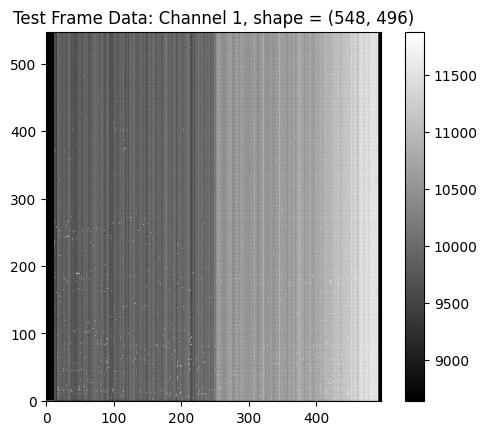

In [190]:
# plot a test frame to test channel splitting
test_data = raw_df.iloc[1]["data"][0]
plot_image(test_data, title=f"Test Frame Data: Channel 1, shape = {test_data.shape}")

full_size: (548, 496)
middle: (274, 248)
test_data shape: (548, 496), roi_data shape: (450, 450)


<Axes: title={'center': 'ROI Data: Center=(274, 248), Width=450'}>

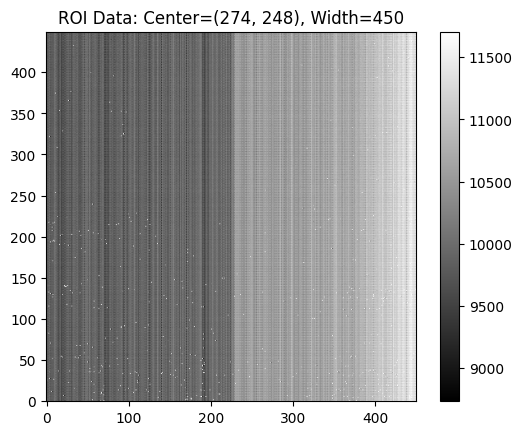

In [191]:
# check the ROI extraction function

full_size = test_data.shape
print(f"full_size: {full_size}")
middle = (full_size[0] // 2, full_size[1] // 2)
print(f"middle: {middle}")
#roi_center = (250, 250)  # (y, x)
roi_center = middle  # (y, x)
roi_width = 450  # pixels
test_data = raw_df.iloc[0]["data"][0]
roi_data = get_roi_data(test_data, roi_center, roi_width)
print(f"test_data shape: {test_data.shape}, roi_data shape: {roi_data.shape}")
plot_image(roi_data, title=f"ROI Data: Center={roi_center}, Width={roi_width}")


25 Unique exposure times (s): [0.14  0.184 0.228 0.272 0.317 0.361 0.405 0.449 0.493 0.538 0.582 0.626
 0.67  0.714 0.758 0.802 0.847 0.891 0.935 0.979 1.023 1.068 1.112 1.156
 1.2  ]
middle: (274, 248)
Found 1 light rows for exptime 0.14s
Found 1 dark rows for exptime 0.14s
Statistical Read Noise at 0.14s: 38.13 ADU


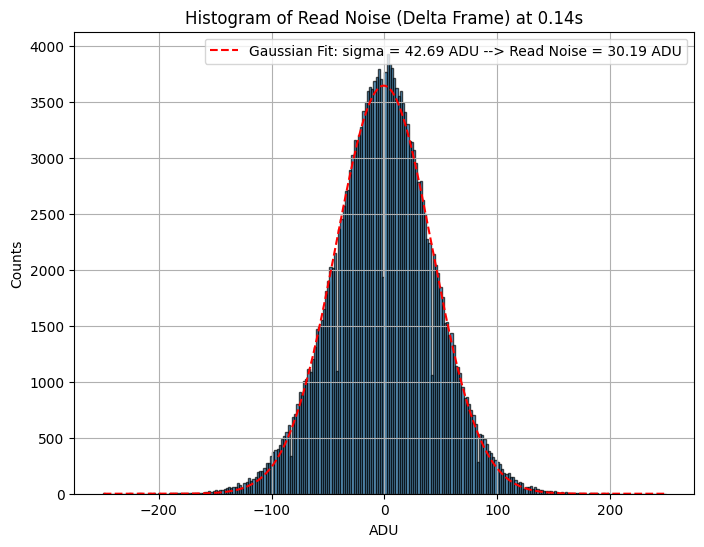

Gaussian Fit at 0.14s: $\sigma$ = 42.69 --> 30.19 ADU
Found 1 light rows for exptime 0.184s
Found 1 dark rows for exptime 0.184s
Found 1 light rows for exptime 0.228s
Found 1 dark rows for exptime 0.228s
Found 1 light rows for exptime 0.272s
Found 1 dark rows for exptime 0.272s
Found 1 light rows for exptime 0.317s
Found 1 dark rows for exptime 0.317s
Found 1 light rows for exptime 0.361s
Found 1 dark rows for exptime 0.361s
Found 1 light rows for exptime 0.405s
Found 1 dark rows for exptime 0.405s
Found 1 light rows for exptime 0.449s
Found 1 dark rows for exptime 0.449s
Found 1 light rows for exptime 0.493s
Found 1 dark rows for exptime 0.493s
Found 1 light rows for exptime 0.538s
Found 1 dark rows for exptime 0.538s
Found 1 light rows for exptime 0.582s
Found 1 dark rows for exptime 0.582s
Found 1 light rows for exptime 0.626s
Found 1 dark rows for exptime 0.626s
Found 1 light rows for exptime 0.67s
Found 1 dark rows for exptime 0.67s
Found 1 light rows for exptime 0.714s
Found 1 da

/var/folders/v4/c0sck65j1l3cwj3lsnz2fs380000gn/T/ipykernel_39736/3974301633.py:131: RuntimeWarning: invalid value encountered in sqrt
  sigma_shot = np.sqrt(sigma_read_plus_shot**2 - read_noise**2)


In [192]:
# process the data
unique_exposure_times = raw_df['exposure_time'].unique()

print(f"{len(unique_exposure_times)} Unique exposure times (s):", unique_exposure_times)

# make a processed dataframe
df = raw_df.copy()

# sort the dataframe to ensure deterministic selection of first row
df = df.sort_values(
    by=["frame_type", "exposure_time", "filename"]
)

results = []

# define ROI
#roi_center = (250, 250)  # (y, x)
#roi_width = 256  # pixels

middle = (274, 248)
print(f"middle: {middle}")
#roi_center = (250, 250)  # (y, x)
roi_center = middle  # (y, x)
roi_width = 450  # pixels

# Now step through each unique exposure time and work through the PTC analysis
#unique_exposure_times = [2.005]

debug_plots = False
for i, exptime in enumerate(unique_exposure_times):
    
    light_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "light")
    ]
    print(f"Found {len(light_rows)} light rows for exptime {exptime}s")


    dark_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "dark")
    ]

    print(f"Found {len(dark_rows)} dark rows for exptime {exptime}s")

    light_data_1 = light_rows.iloc[0]["data"][0]

    #plot_image(light_data_1, title=f"Light Frame 1 - Exptime {exptime}s")

    light_data_2 = light_rows.iloc[0]["data"][1]
    dark_data_1 = dark_rows.iloc[0]["data"][0]
    dark_data_2 = dark_rows.iloc[0]["data"][1]
    all_dark_data = dark_rows.iloc[0]["data"]

    if i==0:
        # calculate the read noise from the shortest exposure time darks
        all_dark_except_last_frame_data = dark_rows.iloc[0]["data"][:-1]
        avg_dark_except_last_frame = np.mean(all_dark_except_last_frame_data, axis=0)
        last_dark_data = dark_rows.iloc[0]["data"][-1]
        
        
    # make an average of all the dark frames for this exposure time
    avg_dark_frame = np.mean(all_dark_data, axis=0)
    

    if roi_center is not None:
        light_data_1 = get_roi_data(light_data_1, roi_center, roi_width)
        light_data_2 = get_roi_data(light_data_2, roi_center, roi_width)
        dark_data_1 = get_roi_data(dark_data_1, roi_center, roi_width)
        dark_data_2 = get_roi_data(dark_data_2, roi_center, roi_width)
        avg_dark_frame = get_roi_data(avg_dark_frame, roi_center, roi_width)

        if i==0:
            avg_dark_except_last_frame = get_roi_data(avg_dark_except_last_frame, roi_center, roi_width)
            last_dark_data = get_roi_data(last_dark_data, roi_center, roi_width)
            
    if i==0:
        #delta_read_noise_frame = last_dark_data - avg_dark_except_last_frame # THIS IS WRONG - should be two independent dark frames, not one frame minus the average of the rest
        delta_read_noise_frame = dark_data_2 - dark_data_1
        read_noise_stat = np.std(delta_read_noise_frame)/np.sqrt(2)
        print(f"Statistical Read Noise at {exptime}s: {read_noise_stat:.2f} ADU")
        
        # make a histogram of delta_read_noise_frame and fit with a gaussian
        plt.figure(figsize=(8,6))
        hist, bin_edges = np.histogram(delta_read_noise_frame.flatten(), range = (-250, 250), bins=256)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', alpha=0.7)
        plt.title(f"Histogram of Read Noise (Delta Frame) at {exptime}s")
        plt.xlabel("ADU")
        plt.ylabel("Counts")
        plt.grid()

        # fit a gaussian to the histogram
        from scipy.optimize import curve_fit
        def gaussian(x, amp, mean, stddev):
            return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))
        gaussian_initial_guess = [np.max(hist), 0, read_noise_stat]
        popt, pcov = curve_fit(gaussian, bin_centers, hist, p0=gaussian_initial_guess)
        amp_fit, mean_fit, stddev_fit = popt   

        # update the readnoise from the fit
        read_noise = stddev_fit/np.sqrt(2)

        plt.plot(bin_centers, gaussian(bin_centers, *popt), 'r--', label=f'Gaussian Fit: sigma = {stddev_fit:.2f} ADU --> Read Noise = {read_noise:.2f} ADU')
        plt.legend()
        plt.show()
        
        print(f"Gaussian Fit at {exptime}s: $\sigma$ = {stddev_fit:.2f} --> {read_noise:.2f} ADU")


    if debug_plots:
        plot_image(light_data_1, title=f"Light Frame 1 - Exptime {exptime}s")
        plot_image(light_data_2, title=f"Light Frame 2 - Exptime {exptime}s")
        plot_image(avg_dark_frame, title=f"Average Dark Frame - Exptime {exptime}s")

    light_avg = np.average(light_data_1)

    signal = light_data_1 - avg_dark_frame
    signal_avg = np.average(signal)

    sigma_total = np.std(signal) # total noise (read + shot + fpn)

    delta = light_data_1 - light_data_2 # difference of two raw light frames

    if debug_plots:
        plot_image(delta, title=f"Delta Frame - Exptime {exptime}s")
    sigma_delta = np.std(delta)
    sigma_read_plus_shot = sigma_delta / np.sqrt(2) # read + shot noise

    # sigma_shot = sigma_read_plus_shot - read_noise
    sigma_shot = np.sqrt(sigma_read_plus_shot**2 - read_noise**2)
    
    # sigma_fpn = np.sqrt(sigma_total**2 - sigma_read_plus_shot**2)
    sigma_fpn = np.sqrt(sigma_total**2 - sigma_read_plus_shot**2)

    results.append({
        "exposure_time": exptime,
        "light_avg": light_avg,
        "signal_avg": signal_avg,
        "sigma_total": sigma_total,
        "delta" : delta,
        "sigma_read_plus_shot": sigma_read_plus_shot,
        "sigma_shot" : sigma_shot,
        "sigma_fpn" : sigma_fpn,
        

    })


results_df = pd.DataFrame(results)



In [193]:
light_rows.iloc[0]["data"]

array([[[28772., 28801., 28757., ...,  3130.,  3031.,  3184.],
        [ 3005.,  3212.,  3132., ...,  2954.,  2967.,  3288.],
        [ 3168.,  3149.,  3123., ...,  3225.,  2950.,  2987.],
        ...,
        [ 3034.,  3258.,  3068., ...,  3135.,  3108.,  3164.],
        [ 3026.,  3250.,  3069., ...,  3127.,  3072.,  3128.],
        [ 3197.,  3093.,  3132., ...,  3108.,  3085.,  3108.]],

       [[28778., 28784., 28777., ...,  3065.,  3067.,  3203.],
        [ 3010.,  3201.,  3159., ...,  2972.,  2925.,  3077.],
        [ 3034.,  3022.,  3003., ...,  3014.,  3086.,  2936.],
        ...,
        [ 3090.,  3164.,  3182., ...,  3136.,  3073.,  3072.],
        [ 3273.,  3116.,  3094., ...,  3080.,  3132.,  3195.],
        [ 3176.,  3080.,  3281., ...,  3117.,  3086.,  3182.]],

       [[28804., 28798., 28788., ...,  3026.,  3077.,  3182.],
        [ 3001.,  3247.,  3144., ...,  2936.,  2960.,  3233.],
        [ 3141.,  3117.,  3107., ...,  2989.,  3026.,  3096.],
        ...,
        [ 32

Fitted Gain from Variance PTC: K = 2.360 e-/ADU
Calculated Gain: K = 2.36 e-/ADU
Maximum Total Noise: 2866.73 ADU
Estimated Full Well: 45776 DN = 108025 e-
Estimated Dynamic Range: 1516.34 
Estimated Dynamic Range: 63.62 dB 
Estimated Dynamic Range: 10.57 stops 


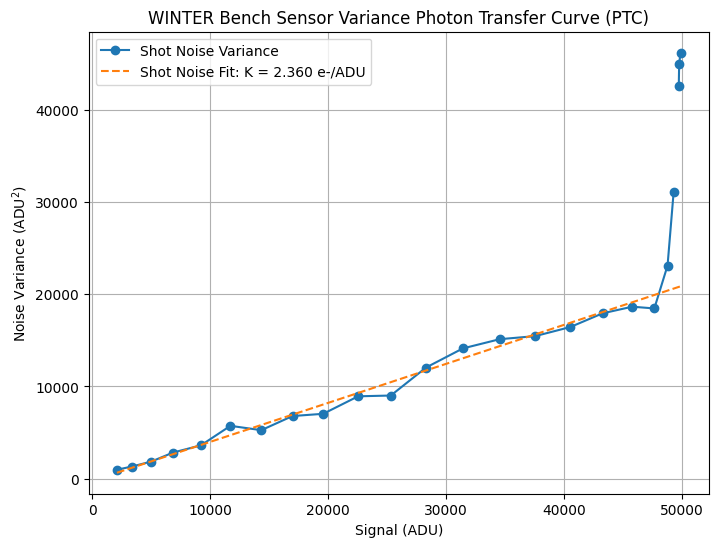

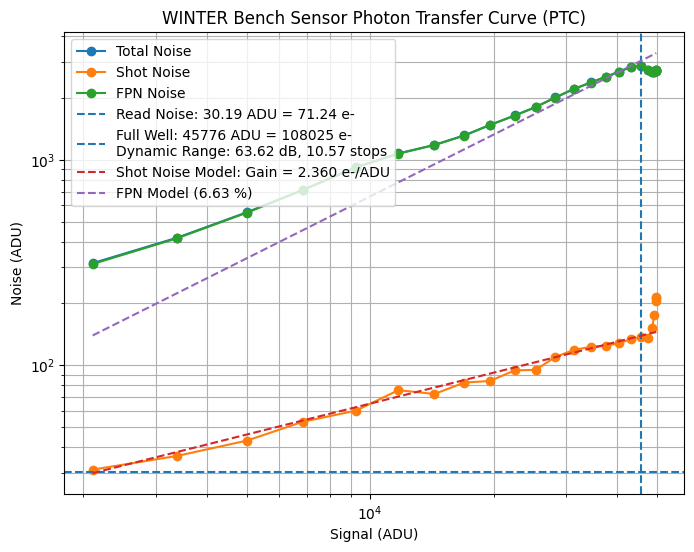

In [194]:
# analyze the PTC
exposure_times = results_df["exposure_time"]
signal = results_df["signal_avg"]
sigma_total = results_df["sigma_total"]
sigma_shot = results_df["sigma_shot"]
sigma_fpn = results_df["sigma_fpn"]



# First do the variance PTC
# Plot the Variance PTC

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(signal, sigma_shot**2, 'o-', label = "Shot Noise Variance")

ax.grid(which='both')

# fit a line to the shot noise variance within the linear region
signal_linear_min = 1000  # ADU
signal_linear_max = 40000  # ADU

linear_region_mask = (signal >= signal_linear_min) & (signal <= signal_linear_max)
signal_linear = signal[linear_region_mask]
sigma_shot_linear = sigma_shot[linear_region_mask]

# fit a line to sigma_shot_linear^2 vs signal_linear
slope, intercept = np.polyfit(signal_linear, sigma_shot_linear**2, 1)

print(f"Fitted Gain from Variance PTC: K = {1/slope:.3f} e-/ADU")
ax.plot(signal, slope * signal + intercept, '--', label = "Shot Noise Fit: K = {:.3f} e-/ADU".format(1/slope))

ax.legend()

ax.set_xlabel("Signal (ADU)")
ax.set_ylabel("Noise Variance (ADU$^2$)")
ax.set_title("WINTER Bench Sensor Variance Photon Transfer Curve (PTC)")
#ax.set_yscale('log')
#ax.set_xscale('log')
gain_from_variance_ptc = 1/slope

# Now do the standard PTC
# use the gain from the variance PTC to plot the gain point
gain = gain_from_variance_ptc

print(f"Calculated Gain: K = {gain:.2f} e-/ADU")

# full well analysis: 
max_sigma_total = np.max(sigma_total)
print(f"Maximum Total Noise: {max_sigma_total:.2f} ADU")
fw = signal[np.argmax(sigma_total)]
print(f"Estimated Full Well: {fw:.0f} DN = {fw*gain:.0f} e-")    
dynamic_range = fw / read_noise
print(f"Estimated Dynamic Range: {dynamic_range:.2f} ")

dynamic_range_db = 20 * np.log10(dynamic_range)
print(f"Estimated Dynamic Range: {dynamic_range_db:.2f} dB ")

dynamic_range_stops = dynamic_range_db/(20*np.log10(2))
print(f"Estimated Dynamic Range: {dynamic_range_stops:.2f} stops ")


fig, ax = plt.subplots(figsize=(8,6))

ax.plot(signal, sigma_total, 'o-', label = "Total Noise")
ax.plot(signal, sigma_shot, 'o-', label = "Shot Noise")
ax.plot(signal, sigma_fpn, 'o-', label = "FPN Noise")
ax.axhline(read_noise, linestyle='--', label=f'Read Noise: {read_noise:.2f} ADU = {read_noise*gain:.2f} e- ')

ax.axvline(fw, linestyle='--', label=f'Full Well: {fw:.0f} ADU = {fw*gain:.0f} e- \nDynamic Range: {dynamic_range_db:.2f} dB, {dynamic_range_stops:.2f} stops')

# plot gain line
shot_noise_gain_line = np.sqrt(signal / gain)
ax.plot(signal, shot_noise_gain_line, '--', label = "Shot Noise Model: Gain = {:.3f} e-/ADU".format(gain))

# pick a point to calculate FPN %
fpn_point_signal = 40000  # ADU
# find the closest signal value in the results_df
fpn_point_idx = (np.abs(signal - fpn_point_signal)).argmin()
fpn_point_signal_actual = signal.iloc[fpn_point_idx]
fpn_value = sigma_fpn.iloc[fpn_point_idx]
fpn_percent = (fpn_value / fpn_point_signal_actual) * 100
fpn_line = (fpn_percent / 100) * signal
ax.plot(signal, fpn_line, '--', label = f"FPN Model ({fpn_percent:.2f} %)")

ax.set_yscale('log')
ax.set_xscale('log')
#ax.set_ylim(1e2, 5e3)
#ax.set_xlim(1e3, 1e5)
ax.grid(which='both')
ax.legend()
ax.set_ylabel("Noise (ADU)")
ax.set_xlabel("Signal (ADU)")
plt.title("WINTER Bench Sensor Photon Transfer Curve (PTC)")

# Save a table that summarizes the results, including the calculated gain, full well, and dynamic range
# should also include the DATA_DIRECTORY, channel, and ROI used for the analysis
# make directory for results if it doesn't exist
results_dir = f"results/ptc_analysis_ch{CHANNEL}_{DATA_DIR.split('/')[-1]}"
os.makedirs(results_dir, exist_ok=True)
summary_table = results_df[["exposure_time", "signal_avg", "sigma_total", "sigma_shot", "sigma_fpn"]]
summary_table.to_csv(f"{results_dir}/ptc_results_summary_ch{CHANNEL}_{DATA_DIR.split('/')[-1]}.csv", index=False)


# save the figures to the results directory
fig.savefig(f"{results_dir}/ptc_curve_ch{CHANNEL}_{DATA_DIR.split('/')[-1]}.png", dpi=300)  


Text(0.5, 0, 'Exposure Time (s)')

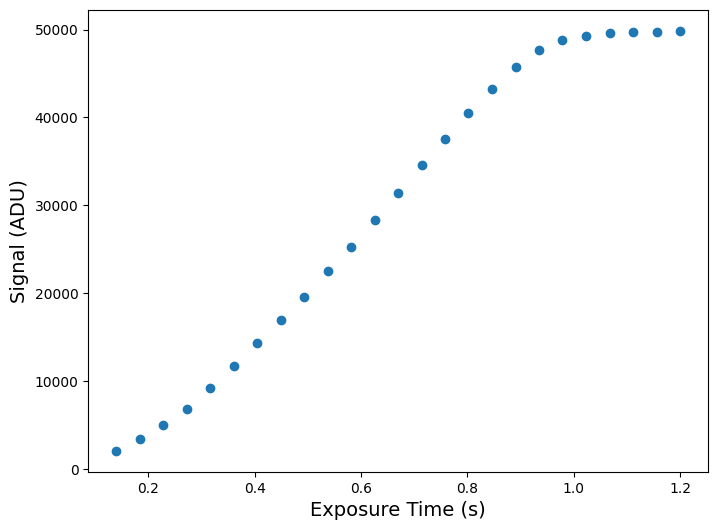

In [195]:
# now plot the ramp

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(exposure_times, signal, 'o')
ax.set_ylabel("Signal (ADU)", fontsize=14)
ax.set_xlabel("Exposure Time (s)", fontsize=14)




Fitted Gain from Variance PTC: K = 2.360 e-/ADU


Text(0.5, 1.0, 'WINTER Bench Sensor Variance Photon Transfer Curve (PTC)')

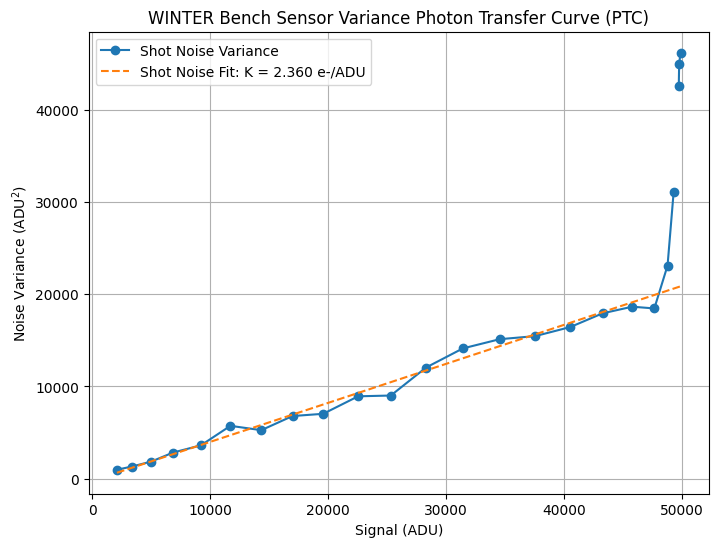

In [196]:
# Plot the Variance PTC

fig, ax = plt.subplots(figsize=(8,6))
#ax.plot(signal, sigma_total**2, 'o-', label = "Total Noise Variance")
ax.plot(signal, sigma_shot**2, 'o-', label = "Shot Noise Variance")

ax.grid(which='both')

# fit a line to the shot noise variance within the linear region
signal_linear_min = 1000  # ADU
signal_linear_max = 40000  # ADU

linear_region_mask = (signal >= signal_linear_min) & (signal <= signal_linear_max)
signal_linear = signal[linear_region_mask]
sigma_shot_linear = sigma_shot[linear_region_mask]

# fit a line to sigma_shot_linear^2 vs signal_linear
slope, intercept = np.polyfit(signal_linear, sigma_shot_linear**2, 1)

print(f"Fitted Gain from Variance PTC: K = {1/slope:.3f} e-/ADU")
ax.plot(signal, slope * signal + intercept, '--', label = "Shot Noise Fit: K = {:.3f} e-/ADU".format(1/slope))

ax.legend()

ax.set_xlabel("Signal (ADU)")
ax.set_ylabel("Noise Variance (ADU$^2$)")
ax.set_title("WINTER Bench Sensor Variance Photon Transfer Curve (PTC)")
#ax.set_yscale('log')
#ax.set_xscale('log')


### 2. Per-Pixel PTC

This uses a pixel-wise approach to remove fixed pattern noise and produce a variance PTC

In [197]:
# Load the bigger ramp data
"""
DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260123", 
                        "1050nm_SWIR_filter_ramp", 
                        "exptimes_25_pts_per_exptime_25_20260123_130822")"""


DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260127", "1000nm_SWIR_filter_ramp", "exptimes_25_pts_per_exptime_25_20260127_133732",
                        )

DATA_DIR = os.path.join(os.getenv("HOME"), "data", "winter", "qe_measurements", 
                        "qe_lab_20260127", "1000nm_SWIR_filter_ramp", "exptimes_50_pts_per_exptime_10_20260127_152824",
                        )

# import the raw data
raw_df = build_database(DATA_DIR)
raw_df.head()


# we need the data stacked per exposure + frame type
raw_df = stack_database(raw_df)
raw_df.head()

# bad exposure times: 1.614, 3.098
bad_exposure_times = [1.614, 1.9, 3.098]

# remove any lines with exposure times in bad_exposure_times
raw_df = raw_df[~raw_df["exposure_time"].isin(bad_exposure_times)]



found 1000 files in /Users/nlourie/data/winter/qe_measurements/qe_lab_20260127/1000nm_SWIR_filter_ramp/exptimes_50_pts_per_exptime_10_20260127_152824


Unique exposure times (s): [0.14  0.16  0.179 0.199 0.218 0.238 0.258 0.277 0.297 0.316 0.336 0.356
 0.375 0.395 0.414 0.434 0.453 0.473 0.493 0.512 0.532 0.551 0.571 0.591
 0.61  0.63  0.649 0.669 0.689 0.708 0.728 0.747 0.767 0.787 0.806 0.826
 0.845 0.865 0.884 0.904 0.924 0.943 0.963 0.982 1.002 1.022 1.041 1.061
 1.08  1.1  ]
middle: (274, 248)
Statistical Read Noise at 0.14s: 55.40 ADU


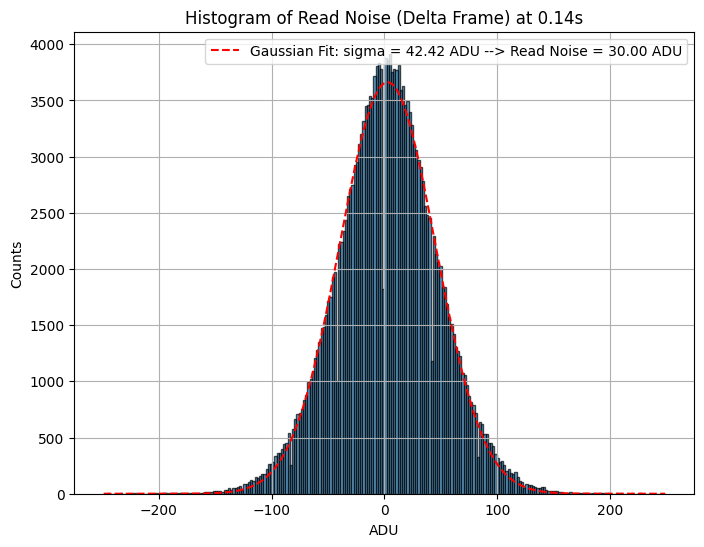

Gaussian Fit Read Noise at 0.14s: 30.00 ADU


In [198]:
# Now calculate the variance PTC pixel-wise

# process the data
unique_exposure_times = raw_df['exposure_time'].unique()

print("Unique exposure times (s):", unique_exposure_times)

# make a processed dataframe
df = raw_df.copy()

# sort the dataframe to ensure deterministic selection of first row
df = df.sort_values(
    by=["frame_type", "exposure_time", "filename"]
)

results = []

# define ROI
#roi_center = (250, 250)  # (y, x)
#roi_width = 256  # pixels

middle =  (274, 248)
print(f"middle: {middle}")
#roi_center = (250, 250)  # (y, x)
roi_center = middle  # (y, x)
roi_width = 450  # pixels

# Now step through each unique exposure time and work through the PTC analysis
#unique_exposure_times = [0.0817]

debug_plots = False
for i, exptime in enumerate(unique_exposure_times):
    
    light_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "light")
    ]



    dark_rows = df[
        (df["exposure_time"] == exptime) &
        (df["frame_type"] == "dark")
    ]
    all_dark_data = dark_rows.iloc[0]["data"]

    all_light_data = light_rows.iloc[0]["data"]
    #print(f"shape of all light data before ROI: {all_light_data.shape}")

    if i==0:
        # calculate the read noise from the shortest exposure time darks
        all_dark_except_last_frame_data = dark_rows.iloc[0]["data"][:-1]
        avg_dark_except_last_frame = np.mean(all_dark_except_last_frame_data, axis=0)
        last_dark_data = dark_rows.iloc[0]["data"][-1]
        
        
    # make an average of all the dark frames for this exposure time
    avg_dark_frame = np.mean(all_dark_data, axis=0)
    avg_light_frame = np.mean(all_light_data, axis=0)

    if roi_center is not None:

        avg_light_frame = get_roi_data(avg_light_frame, roi_center, roi_width)
        avg_dark_frame = get_roi_data(avg_dark_frame, roi_center, roi_width)

        all_light_data = get_roi_data(all_light_data, roi_center, roi_width)
        all_dark_data = get_roi_data(all_dark_data, roi_center, roi_width)

        if i==0:
            avg_dark_except_last_frame = get_roi_data(avg_dark_except_last_frame, roi_center, roi_width)
            last_dark_data = get_roi_data(last_dark_data, roi_center, roi_width)
            
    if i==0:
        # delta_read_noise_frame = last_dark_data - avg_dark_except_last_frame # THIS IS WRONG - should be two independent dark frames, not one frame minus the average of the rest
        delta_read_noise_frame = all_dark_data[1] - all_dark_data[0]
        read_noise_stat = np.std(delta_read_noise_frame)
        print(f"Statistical Read Noise at {exptime}s: {read_noise_stat:.2f} ADU")
        
        # make a histogram of delta_read_noise_frame and fit with a gaussian
        plt.figure(figsize=(8,6))
        hist, bin_edges = np.histogram(delta_read_noise_frame.flatten(), range = (-250, 250),bins=256)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers, hist, width=np.diff(bin_edges), edgecolor='black', alpha=0.7)
        plt.title(f"Histogram of Read Noise (Delta Frame) at {exptime}s")
        plt.xlabel("ADU")
        plt.ylabel("Counts")
        plt.grid()

        # fit a gaussian to the histogram
        from scipy.optimize import curve_fit
        def gaussian(x, amp, mean, stddev):
            return amp * np.exp(-((x - mean) ** 2) / (2 * stddev ** 2))
        gaussian_initial_guess = [np.max(hist), 0, read_noise_stat]
        popt, pcov = curve_fit(gaussian, bin_centers, hist, p0=gaussian_initial_guess)
        amp_fit, mean_fit, stddev_fit = popt 

        # update the readnoise from the fit
        read_noise = stddev_fit/np.sqrt(2)

        plt.plot(bin_centers, gaussian(bin_centers, *popt), 'r--', label=f'Gaussian Fit: sigma = {stddev_fit:.2f} ADU --> Read Noise = {read_noise:.2f} ADU')
        plt.legend()
        plt.show()
        
        print(f"Gaussian Fit Read Noise at {exptime}s: {read_noise:.2f} ADU")

    # Proceed with the rest of the analysis

    # make a frame that is the difference of the avg light and dark frames
    mean_diff_frame = avg_light_frame - avg_dark_frame
    mean_diff = np.mean(mean_diff_frame)
    
    # make the std deviation frame that is the pixel-wise std deviation of all light frames minus avg dark frame
    #print(f"shape of all light data: {all_light_data.shape}")
    diff_frames = all_light_data - avg_dark_frame  # shape (n, roi_width, roi_width)
    stddev_frame = np.std(diff_frames, axis=0)  # shape (roi_width, roi_width)

    var_frame = stddev_frame**2

    results.append({
        "exposure_time": exptime,
        "mean_light_frame": avg_light_frame,
        "mean_dark_frame": avg_dark_frame,
        "mean_frame": mean_diff_frame,
        "var_frame": var_frame,
        "stddev_frame": stddev_frame,
        "mean": mean_diff,
        "var": np.mean(var_frame),
        "std": np.mean(stddev_frame),
    })

pixelwise_results_df = pd.DataFrame(results)

In [199]:
from scipy.interpolate import CubicSpline, UnivariateSpline
from typing import Optional, Tuple, Dict, Any
def fit_photon_transfer_curve_simple(
    df_filtered: pd.DataFrame
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Fit the pixel-wise photon transfer curve
    """
    # Stack all mean and variance frames
    arr_mean = np.stack(df_filtered["mean_frame"].values)
    arr_var = np.stack(df_filtered["var_frame"].values)

    # Calculate pixel-wise slope using centered differences
    x_mean = np.nanmean(arr_mean, axis=0)
    y_mean = np.nanmean(arr_var, axis=0)

    print(f"x_mean.shape: {x_mean.shape}")
    print(f"y_mean.shape: {y_mean.shape}")

    diff_x = arr_mean - x_mean
    diff_y = arr_var - y_mean

    num = np.nansum(diff_x * diff_y, axis=0)
    den = np.nansum(diff_x * diff_x, axis=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        slope_image = num / den
        slope_image[den == 0] = np.nan

    intercept_image = y_mean - slope_image * x_mean
    gain_image = 1.0 / slope_image  # gain = 1/slope

    return slope_image, intercept_image, gain_image

def fit_photon_transfer_curve_masked_no_sigma_clip(
    df_filtered,
    signal_min: float = 10_000,
    signal_max: float = 40_000,
    n_plot: int = 0,
    seed: Optional[int] = 0,
    robust_percentile_clip: Optional[Tuple[float, float]] = (1.0, 99.0),
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict[str, Any]]:
    """
    Fit pixel-wise PTC: var = slope * mean + intercept, gain = 1/slope,
    using a global mask based on ROI-mean signal per exposure point.

    Args:
        df_filtered: dataframe with columns "mean_frame" and "var_frame"
                     each row corresponds to one exposure level / point.
        signal_min/max: only use exposure points whose ROI-mean(mean_frame)
                        lies within [signal_min, signal_max].
        n_plot: number of random pixels to plot for sanity check. 0 disables.
        seed: RNG seed for reproducible pixel selection.
        robust_percentile_clip:
            If not None, clip plotted y-values (variance) to these percentiles
            for nicer visualization (does NOT affect fitting).

    Returns:
        slope_image: (y, x)
        intercept_image: (y, x)
        gain_image: (y, x)
        info: dict with mask and helpful arrays
    """
    # Stack into arrays: (n_points, y, x)
    arr_mean = np.stack(df_filtered["mean_frame"].values)
    arr_var = np.stack(df_filtered["var_frame"].values)

    # Global (one-per-point) mean used to choose the fit region
    exp_means = np.array([np.nanmean(m) for m in df_filtered["mean_frame"].values])
    use = (exp_means >= signal_min) & (exp_means <= signal_max)

    if np.count_nonzero(use) < 2:
        raise ValueError(
            f"Not enough points in mask: {np.count_nonzero(use)}. "
            f"Check signal_min/max or your exp_means range."
        )

    arr_mean_fit = arr_mean[use]  # (n_fit, y, x)
    arr_var_fit = arr_var[use]

    # OLS slope per pixel (across the selected exposure points)
    x_bar = np.nanmean(arr_mean_fit, axis=0)  # (y, x)
    y_bar = np.nanmean(arr_var_fit, axis=0)

    dx = arr_mean_fit - x_bar
    dy = arr_var_fit - y_bar

    num = np.nansum(dx * dy, axis=0)
    den = np.nansum(dx * dx, axis=0)

    slope = np.divide(num, den, out=np.full_like(num, np.nan), where=(den != 0))
    intercept = y_bar - slope * x_bar
    gain = np.divide(1.0, slope, out=np.full_like(slope, np.nan), where=np.isfinite(slope) & (slope != 0))

    info = {
        "use_mask": use,
        "exp_means": exp_means,
        "signal_min": signal_min,
        "signal_max": signal_max,
        "n_points_total": arr_mean.shape[0],
        "n_points_used": int(np.count_nonzero(use)),
    }

    # -----------------------
    # Optional sanity plots
    # -----------------------
    if n_plot and n_plot > 0:
        rng = np.random.default_rng(seed)
        ny, nx = arr_mean.shape[1], arr_mean.shape[2]

        # Pick random pixel coords
        ys = rng.integers(0, ny, size=n_plot)
        xs = rng.integers(0, nx, size=n_plot)

        # 1) Show exp_means and mask
        plt.figure(figsize=(7, 4))
        idx = np.arange(len(exp_means))
        plt.plot(idx, exp_means, "o-")
        plt.axhline(signal_min, linestyle="--")
        plt.axhline(signal_max, linestyle="--")
        # highlight used points
        plt.plot(idx[use], exp_means[use], "ks", label="used")
        plt.xlabel("PTC point index")
        plt.ylabel("ROI mean signal (ADU)")
        plt.title("Global mask for pixelwise PTC fit")
        plt.grid(True, which="both")
        plt.legend()
        plt.show()

        # 2) Plot random pixel PTCs with fitted line
        for j, (yy, xx) in enumerate(zip(ys, xs), start=1):
            x_all = arr_mean[:, yy, xx]
            y_all = arr_var[:, yy, xx]

            # For plot: use only finite values
            m_all = np.isfinite(x_all) & np.isfinite(y_all)

            x_fit = arr_mean_fit[:, yy, xx]
            y_fit = arr_var_fit[:, yy, xx]
            m_fit = np.isfinite(x_fit) & np.isfinite(y_fit)

            if np.count_nonzero(m_fit) < 2 or not np.isfinite(slope[yy, xx]):
                print(f"[plot {j}] pixel (y={yy}, x={xx}) skipped (insufficient finite fit points).")
                continue

            # fitted line over the fit-range of x
            x_line = np.linspace(np.nanmin(x_fit[m_fit]), np.nanmax(x_fit[m_fit]), 100)
            y_line = slope[yy, xx] * x_line + intercept[yy, xx]

            plt.figure(figsize=(6, 5))
            plt.plot(x_all[m_all], y_all[m_all], "o", alpha=0.6, label="all points")
            plt.plot(x_fit[m_fit], y_fit[m_fit], "ks", label="used (masked)")
            plt.plot(x_line, y_line, "-", label=f"fit: slope={slope[yy,xx]:.4g}, gain={gain[yy,xx]:.4g}")

            if robust_percentile_clip is not None:
                lo, hi = robust_percentile_clip
                ylo, yhi = np.nanpercentile(y_all[m_all], [lo, hi])
                plt.ylim(ylo, yhi)

            plt.xlabel("Mean signal (ADU) [pixel]")
            plt.ylabel("Variance (ADU^2) [pixel]")
            plt.title(f"Pixel PTC sanity check {j}/{n_plot} at (y={yy}, x={xx})")
            plt.grid(True, which="both")
            plt.legend()
            plt.show()

    return slope, intercept, gain, info

def _mad_sigma(resid: np.ndarray, axis: int = 0) -> np.ndarray:
    """
    Robust sigma estimate via MAD: sigma ~= 1.4826 * median(|x - median(x)|)
    """
    med = np.nanmedian(resid, axis=axis)
    mad = np.nanmedian(np.abs(resid - np.expand_dims(med, axis=axis)), axis=axis)
    return 1.4826 * mad


def fit_photon_transfer_curve_masked(
    df_filtered,
    signal_min: float = 10_000,
    signal_max: float = 40_000,
    n_plot: int = 0,
    seed: Optional[int] = 0,
    robust_percentile_clip: Optional[Tuple[float, float]] = (1.0, 99.0),

    # --- new: iterative residual sigma clipping ---
    n_clip_iters: int = 0,
    clip_sigma: float = 4.0,
    min_points_per_pixel: int = 3,
    use_mad_sigma: bool = True,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, Dict[str, Any]]:
    """
    Fit pixel-wise PTC: var = slope * mean + intercept, gain = 1/slope,
    using a global mask based on ROI-mean signal per exposure point, with optional
    iterative sigma clipping on residuals (per pixel).

    Args:
        df_filtered: dataframe with columns "mean_frame" and "var_frame"
                     each row corresponds to one exposure level / point.
        signal_min/max: only use exposure points whose ROI-mean(mean_frame)
                        lies within [signal_min, signal_max].
        n_plot: number of random pixels to plot for sanity check. 0 disables.
        seed: RNG seed for reproducible pixel selection.
        robust_percentile_clip:
            If not None, clip plotted y-values (variance) to these percentiles
            for nicer visualization (does NOT affect fitting).

        n_clip_iters: number of sigma-clipping iterations on residuals within the masked region.
                     0 disables clipping (original behavior).
        clip_sigma: threshold in sigma units for masking residual outliers.
        min_points_per_pixel: after clipping, require at least this many points for a pixel fit;
                              otherwise slope/intercept/gain set to NaN for that pixel.
        use_mad_sigma: if True, sigma per pixel is estimated robustly via MAD; else uses std.

    Returns:
        slope_image: (y, x)
        intercept_image: (y, x)
        gain_image: (y, x)
        info: dict with masks and helpful arrays
    """
    # Stack into arrays: (n_points, y, x)
    arr_mean = np.stack(df_filtered["mean_frame"].values)
    arr_var = np.stack(df_filtered["var_frame"].values)

    # Global (one-per-point) mean used to choose the fit region
    exp_means = np.array([np.nanmean(m) for m in df_filtered["mean_frame"].values])
    use_global = (exp_means >= signal_min) & (exp_means <= signal_max)

    n_used = int(np.count_nonzero(use_global))
    if n_used < 2:
        raise ValueError(
            f"Not enough points in mask: {n_used}. "
            f"Check signal_min/max or your exp_means range."
        )

    # Restrict to globally selected points (keep point axis length = n_fit_points)
    arr_mean_fit = arr_mean[use_global]  # (n_fit, y, x)
    arr_var_fit  = arr_var[use_global]

    n_fit, ny, nx = arr_mean_fit.shape

    # Pixelwise mask over the fit points: start with finite-only
    fit_mask = np.isfinite(arr_mean_fit) & np.isfinite(arr_var_fit)  # (n_fit, y, x)

    # Helper: weighted OLS per pixel with per-point mask
    def _ols_per_pixel(x: np.ndarray, y: np.ndarray, m: np.ndarray):
        """
        x,y,m shapes: (n_fit, y, x)
        returns slope, intercept, npts (y,x)
        """
        w = m.astype(np.float32)

        sum_w  = np.nansum(w, axis=0)
        sum_wx = np.nansum(w * x, axis=0)
        sum_wy = np.nansum(w * y, axis=0)

        # Avoid division by zero
        x_bar = np.divide(sum_wx, sum_w, out=np.full((ny, nx), np.nan), where=(sum_w > 0))
        y_bar = np.divide(sum_wy, sum_w, out=np.full((ny, nx), np.nan), where=(sum_w > 0))

        dx = x - x_bar  # broadcasts over point axis
        dy = y - y_bar

        num = np.nansum(w * dx * dy, axis=0)
        den = np.nansum(w * dx * dx, axis=0)

        slope = np.divide(num, den, out=np.full((ny, nx), np.nan), where=(den != 0))
        intercept = y_bar - slope * x_bar

        npts = sum_w  # number of points used per pixel (float but integer-valued)
        return slope, intercept, npts

    # Initial fit
    slope, intercept, npts = _ols_per_pixel(arr_mean_fit, arr_var_fit, fit_mask)

    # Optional iterative sigma clipping on residuals (per pixel)
    if n_clip_iters and n_clip_iters > 0:
        for it in range(n_clip_iters):
            # residuals for currently-fit model
            resid = arr_var_fit - (slope[None, :, :] * arr_mean_fit + intercept[None, :, :])

            # sigma per pixel from residuals over currently-included points
            resid_in = np.where(fit_mask, resid, np.nan)

            if use_mad_sigma:
                sigma = _mad_sigma(resid_in, axis=0)
            else:
                sigma = np.nanstd(resid_in, axis=0)

            # Avoid zero sigma (perfect fits or too-few points)
            sigma = np.where(sigma > 0, sigma, np.nan)

            # new mask: keep points within clip_sigma
            keep = np.abs(resid) <= (clip_sigma * sigma[None, :, :])

            new_fit_mask = fit_mask & keep

            # Enforce minimum points per pixel
            new_npts = np.nansum(new_fit_mask.astype(np.float32), axis=0)
            # Pixels with too few points => invalidate all points (so fit becomes NaN)
            too_few = new_npts < float(min_points_per_pixel)
            if np.any(too_few):
                new_fit_mask[:, too_few] = False

            # Check for convergence (no mask change)
            if np.array_equal(new_fit_mask, fit_mask):
                break

            fit_mask = new_fit_mask
            slope, intercept, npts = _ols_per_pixel(arr_mean_fit, arr_var_fit, fit_mask)

    # Final gain
    gain = np.divide(
        1.0, slope,
        out=np.full_like(slope, np.nan),
        where=np.isfinite(slope) & (slope != 0)
    )

    info = {
        "use_mask": use_global,                 # global mask over original points (n_points,)
        "exp_means": exp_means,
        "signal_min": signal_min,
        "signal_max": signal_max,
        "n_points_total": int(arr_mean.shape[0]),
        "n_points_used_global": int(np.count_nonzero(use_global)),

        # new:
        "clip_mask_fit": fit_mask,              # (n_fit, y, x) pixelwise mask after clipping
        "n_points_per_pixel": npts,             # (y, x) number of points used per pixel (after clipping)
        "n_clip_iters": int(n_clip_iters),
        "clip_sigma": float(clip_sigma),
        "min_points_per_pixel": int(min_points_per_pixel),
        "use_mad_sigma": bool(use_mad_sigma),
    }

    # -----------------------
    # Optional sanity plots
    # -----------------------
    if n_plot and n_plot > 0:
        rng = np.random.default_rng(seed)

        ys = rng.integers(0, ny, size=n_plot)
        xs = rng.integers(0, nx, size=n_plot)

        # 1) Show exp_means and global mask
        plt.figure(figsize=(7, 4))
        idx = np.arange(len(exp_means))
        plt.plot(idx, exp_means, "o-")
        plt.axhline(signal_min, linestyle="--")
        plt.axhline(signal_max, linestyle="--")
        plt.plot(idx[use_global], exp_means[use_global], "ks", label="used (global)")
        plt.xlabel("PTC point index")
        plt.ylabel("ROI mean signal (ADU)")
        plt.title("Global mask for pixelwise PTC fit")
        plt.grid(True, which="both")
        plt.legend()
        plt.show()

        # 2) Plot random pixel PTCs with fitted line; show which points survived clipping
        for j, (yy, xx) in enumerate(zip(ys, xs), start=1):
            x_all = arr_mean[:, yy, xx]
            y_all = arr_var[:, yy, xx]
            m_all = np.isfinite(x_all) & np.isfinite(y_all)

            # Points in global fit region for this pixel
            x_fit = arr_mean_fit[:, yy, xx]
            y_fit = arr_var_fit[:, yy, xx]

            # Pixelwise final mask (after clipping) within the fit-region points
            m_final = fit_mask[:, yy, xx] & np.isfinite(x_fit) & np.isfinite(y_fit)

            if np.count_nonzero(m_final) < 2 or not np.isfinite(slope[yy, xx]):
                print(f"[plot {j}] pixel (y={yy}, x={xx}) skipped (insufficient final fit points).")
                continue

            x_line = np.linspace(np.nanmin(x_fit[m_final]), np.nanmax(x_fit[m_final]), 100)
            y_line = slope[yy, xx] * x_line + intercept[yy, xx]

            plt.figure(figsize=(6, 5))
            plt.plot(x_all[m_all], y_all[m_all], "o", alpha=0.5, label="all points")
            plt.plot(x_fit, y_fit, "k.", alpha=0.3, label="in global region")
            plt.plot(x_fit[m_final], y_fit[m_final], "ks", label="used (after clip)")
            plt.plot(x_line, y_line, "-", label=f"fit: slope={slope[yy,xx]:.4g}, gain={gain[yy,xx]:.4g}\nN={int(np.nansum(m_final))}")

            if robust_percentile_clip is not None:
                lo, hi = robust_percentile_clip
                ylo, yhi = np.nanpercentile(y_all[m_all], [lo, hi])
                plt.ylim(ylo, yhi)

            plt.xlabel("Mean signal (ADU) [pixel]")
            plt.ylabel("Variance (ADU$^2$) [pixel]")
            plt.title(f"Pixel PTC sanity check {j}/{n_plot} at (y={yy}, x={xx})")
            plt.grid(True, which="both")
            plt.legend()
            plt.show()

    return slope, intercept, gain, info


In [200]:


def plot_gain_histogram(gain_image: np.ndarray, nominal_gain: float = 4.2, 
                        nbins: Optional[int] = 1000, 
                        hist_fit_min_counts: int = 100,
                        hist_range: Optional[Tuple[float, float]] = None,
                        spline_x_points: int = 1000,
                        spline_type: str = 'univariate'):
    """
    Plot histogram of gains with analysis
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create histogram
    gain_flat = np.ravel(gain_image[~np.isnan(gain_image)])

    if hist_range is None:
        hist_range = (0, 10*max(nominal_gain, max(gain_flat)))
    hist, bins = np.histogram(gain_flat, bins=nbins, range=hist_range)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax.semilogy(bin_centers, hist, ".", alpha=0.5, label="Data")
    ax.set_title("Pixel-wise PTC: Gain Histogram")

    # Fit spline to histogram peak region
    hist_clipcond = hist > hist_fit_min_counts
    if np.any(hist_clipcond):
        xhist_clip = bin_centers[hist_clipcond]
        yhist_clip = hist[hist_clipcond]

        # Spline fit
        if spline_type == 'cubic':
            cs = CubicSpline(xhist_clip, yhist_clip)
            xhist_fine = np.linspace(xhist_clip[0], xhist_clip[-1], spline_x_points)
            yhist_fine = cs(xhist_fine)
            ax.plot(xhist_fine, yhist_fine, "r-", label="Spline Fit")
        elif spline_type == 'univariate':
            # Choose a smoothing factor.
            # Rule of thumb: s ≈ N * (noise_sigma^2). If you don't know noise_sigma, start with s=N or 0.5*N.
            N = len(xhist_clip)
            s = 2.0 * N  # try N, 5*N, 0.2*N, etc.
            us = UnivariateSpline(xhist_clip, yhist_clip, s=s)
            xhist_fine = np.linspace(xhist_clip[0], xhist_clip[-1], spline_x_points)
            yhist_fine = us(xhist_fine)
            ax.plot(xhist_fine, yhist_fine, "r-", label="Spline Fit")

        # Find peak
        peak_idx = np.argmax(yhist_fine)
        peak_x = xhist_fine[peak_idx]
        peak_y = yhist_fine[peak_idx]

        print(f"Peak Gain = {peak_x:.3f} ADU/e")
        print(f"Peak Slope = {1/peak_x:.3f} e/ADU")

        # also put the mean Gain
        mean_gain = np.mean(gain_flat)
        print(f"Mean Gain = {mean_gain:.3f} e/ADU")
        ax.axvline(mean_gain, color="orange", linestyle="--", label=f"Mean Gain={mean_gain:.3f} e/ADU")   

        ax.axvline(
            peak_x,
            color="k",
            linestyle="--",
            label=f"Peak: Gain={peak_x:.3f}, Slope={1/peak_x:.3f} e/ADU",
        )

        # Calculate FWHM
        half_max = peak_y / 2
        indices_above_half = np.where(yhist_fine > half_max)[0]
        if len(indices_above_half) > 0:
            left_idx = indices_above_half[0]
            right_idx = indices_above_half[-1]
            fwhm = xhist_fine[right_idx] - xhist_fine[left_idx]
            std_from_fwhm = fwhm / 2.355

            print(f"FWHM = {fwhm:.3f}")
            print(f"Std from FWHM = {std_from_fwhm:.3f}")

            ax.axvline(peak_x - fwhm / 2, color="b", linestyle="--", alpha=0.5)
            ax.axvline(
                peak_x + fwhm / 2,
                color="b",
                linestyle="--",
                alpha=0.5,
                label=f"FWHM={fwhm:.3f}",
            )

            # Plot 3-sigma lines
            N = 3
            ax.axvline(
                peak_x - N * std_from_fwhm, color="m", linestyle="--", alpha=0.5
            )
            ax.axvline(
                peak_x + N * std_from_fwhm,
                color="m",
                linestyle="--",
                alpha=0.5,
                label=f"±{N}σ = ±{N*std_from_fwhm:.3f}",
            )

    # Plot nominal gain
    ax.axvline(
        nominal_gain,
        color="g",
        linestyle="--",
        label=f"Nominal: Gain={nominal_gain:.3f} e/ADU",
    )

    ax.set_xlabel("Gain (e/ADU)")
    ax.set_ylabel("Number of pixels")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

def plot_slope_histogram(slope_image: np.ndarray, nominal_gain: float = 4.2, 
                            nbins: int = 1000, 
                            hist_fit_min_counts: int = 100,
                            hist_range: Optional[Tuple[float, float]] = None,
                            spline_x_points: int = 1000):
    """
    Plot histogram of gains with analysis
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create histogram
    slope_flat = np.ravel(slope_image[~np.isnan(slope_image)])
    if hist_range is None:
        hist_range = (0, 10*max(1/nominal_gain, max(slope_flat)))
    hist, bins = np.histogram(slope_flat, bins=nbins, range=hist_range)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    ax.semilogy(bin_centers, hist, ".", alpha=0.5, label="Data")
    ax.set_title("Pixel-wise PTC: Slope Histogram (Inverse Gain)")

    # Fit spline to histogram peak region
    hist_clipcond = hist > hist_fit_min_counts
    if np.any(hist_clipcond):
        xhist_clip = bin_centers[hist_clipcond]
        yhist_clip = hist[hist_clipcond]

        # Spline fit
        cs = CubicSpline(xhist_clip, yhist_clip)
        xhist_fine = np.linspace(xhist_clip[0], xhist_clip[-1], spline_x_points)
        yhist_fine = cs(xhist_fine)
        ax.plot(xhist_fine, yhist_fine, "r-", label="Spline Fit")

        # Find peak
        peak_idx = np.argmax(yhist_fine)
        peak_x = xhist_fine[peak_idx]
        peak_y = yhist_fine[peak_idx]

        print(f"Peak Slope = {peak_x:.3f} ADU/e")
        print(f"Peak Gain = {1/peak_x:.3f} e/ADU")

        ax.axvline(
            peak_x,
            color="k",
            linestyle="--",
            label=f"Peak: Slope={peak_x:.3f}, Gain={1/peak_x:.3f} e/ADU",
        )

        # Calculate FWHM
        half_max = peak_y / 2
        indices_above_half = np.where(yhist_fine > half_max)[0]
        if len(indices_above_half) > 0:
            left_idx = indices_above_half[0]
            right_idx = indices_above_half[-1]
            fwhm = xhist_fine[right_idx] - xhist_fine[left_idx]
            std_from_fwhm = fwhm / 2.355

            print(f"FWHM = {fwhm:.3f}")
            print(f"Std from FWHM = {std_from_fwhm:.3f}")

            ax.axvline(peak_x - fwhm / 2, color="b", linestyle="--", alpha=0.5)
            ax.axvline(
                peak_x + fwhm / 2,
                color="b",
                linestyle="--",
                alpha=0.5,
                label=f"FWHM={fwhm:.3f}",
            )

            # Plot 3-sigma lines
            N = 3
            ax.axvline(
                peak_x - N * std_from_fwhm, color="m", linestyle="--", alpha=0.5
            )
            ax.axvline(
                peak_x + N * std_from_fwhm,
                color="m",
                linestyle="--",
                alpha=0.5,
                label=f"±{N}σ = ±{N*std_from_fwhm:.3f}",
            )

    # Plot nominal gain
    nominal_slope = 1 / nominal_gain
    ax.axvline(
        nominal_slope,
        color="g",
        linestyle="--",
        label=f"Nominal: Slope={nominal_slope:.3f}, Gain={nominal_gain:.3f} e/ADU",
    )

    ax.set_xlabel("Inverse Gain (ADU/e)")
    ax.set_ylabel("Number of pixels")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

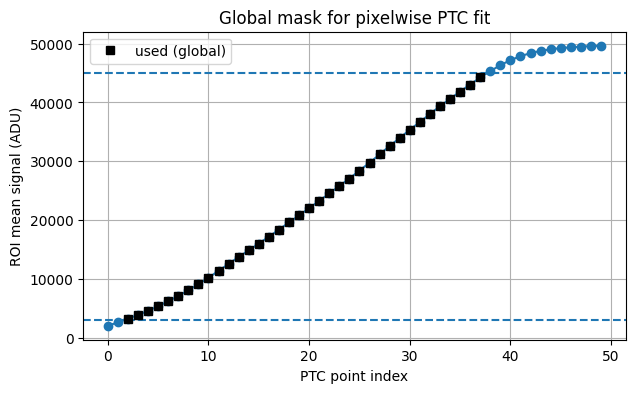

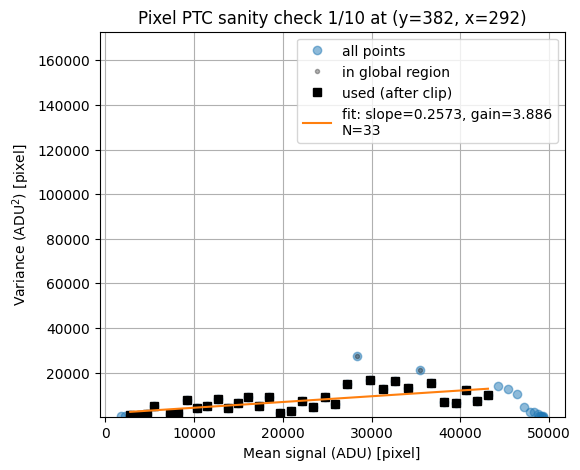

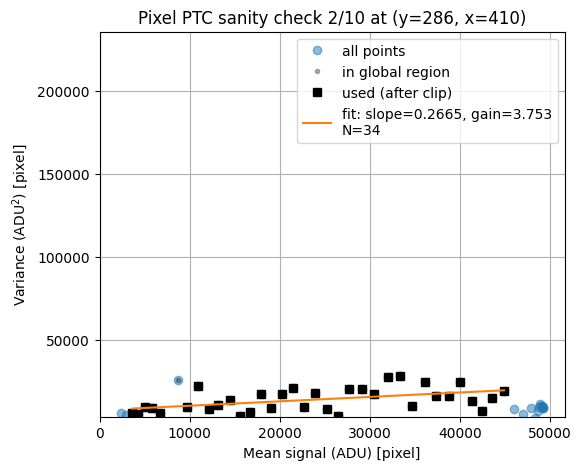

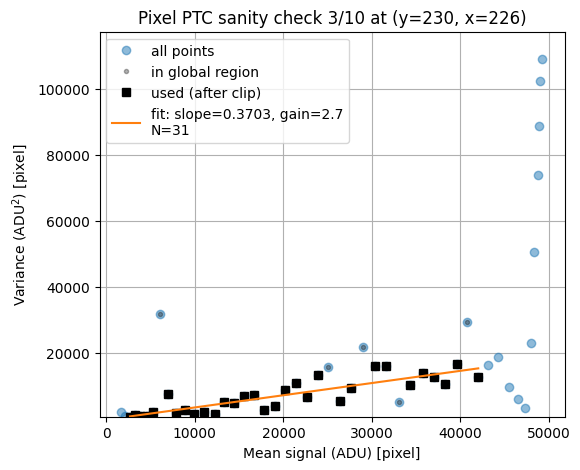

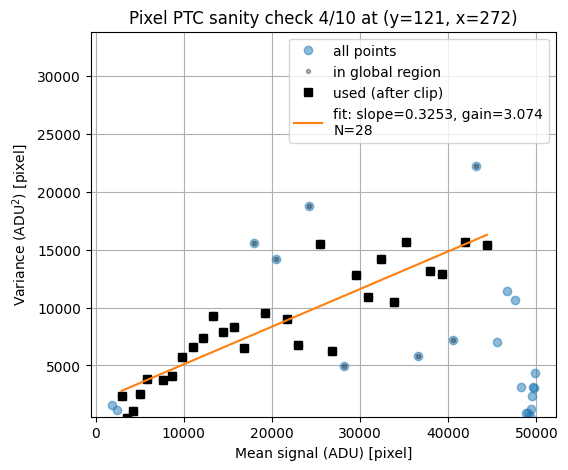

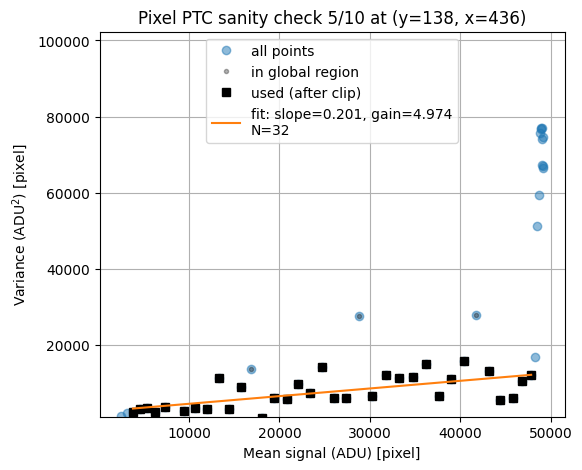

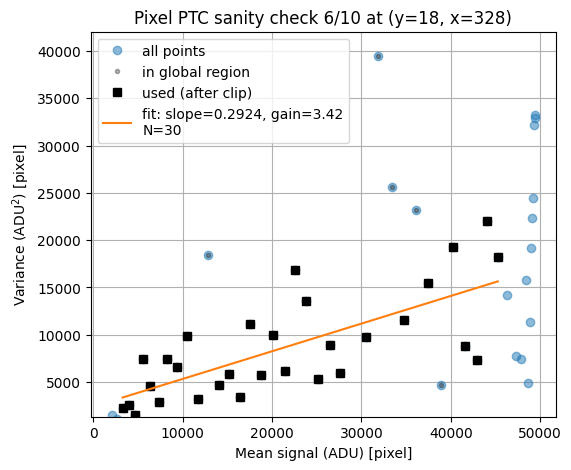

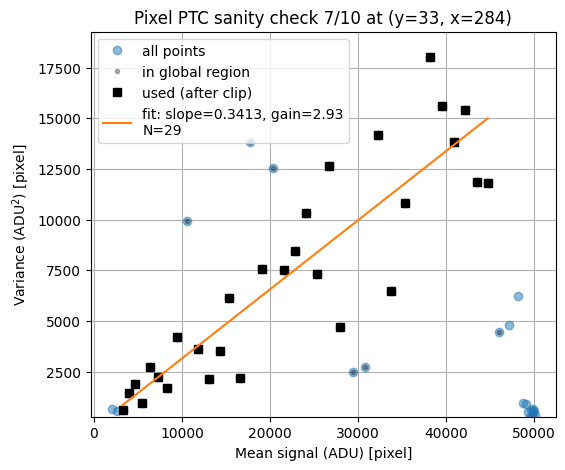

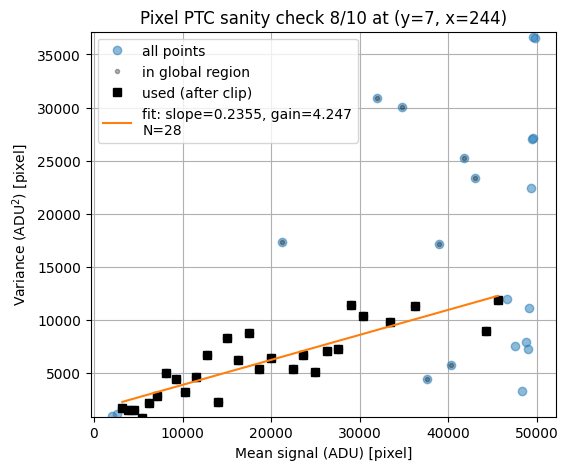

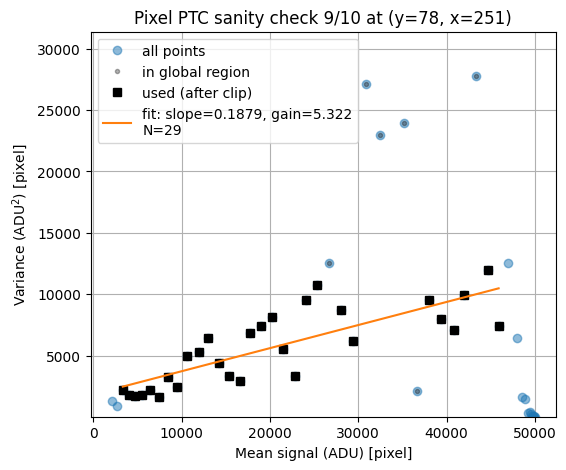

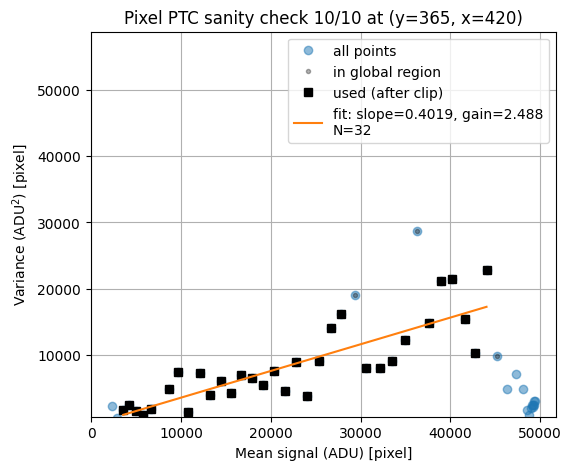

Peak Gain = 3.275 ADU/e
Peak Slope = 0.305 e/ADU
Mean Gain = 4.207 e/ADU
FWHM = 2.191
Std from FWHM = 0.930
Peak Slope = 0.250 ADU/e
Peak Gain = 4.004 e/ADU
FWHM = 0.182
Std from FWHM = 0.077


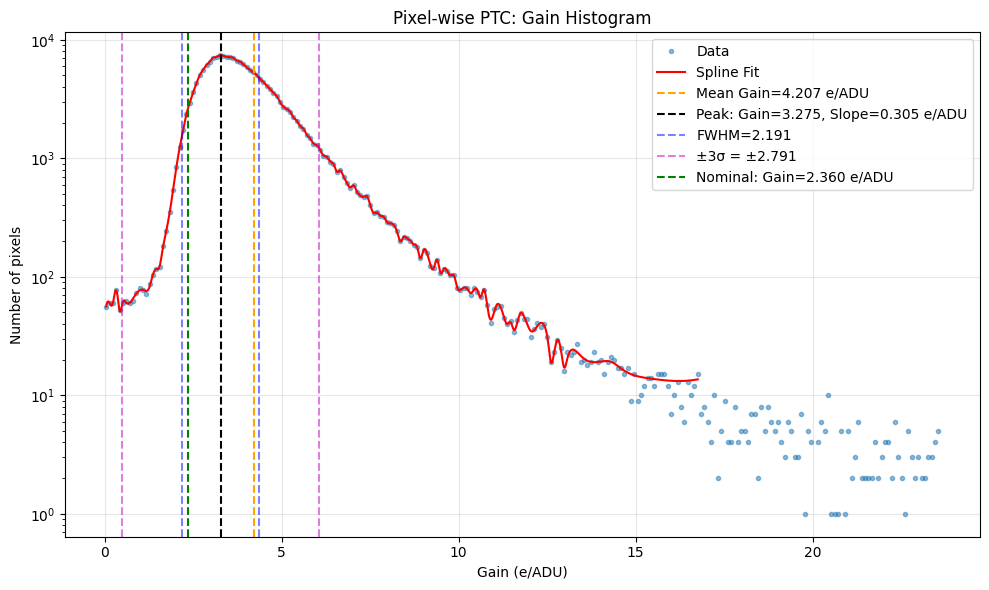

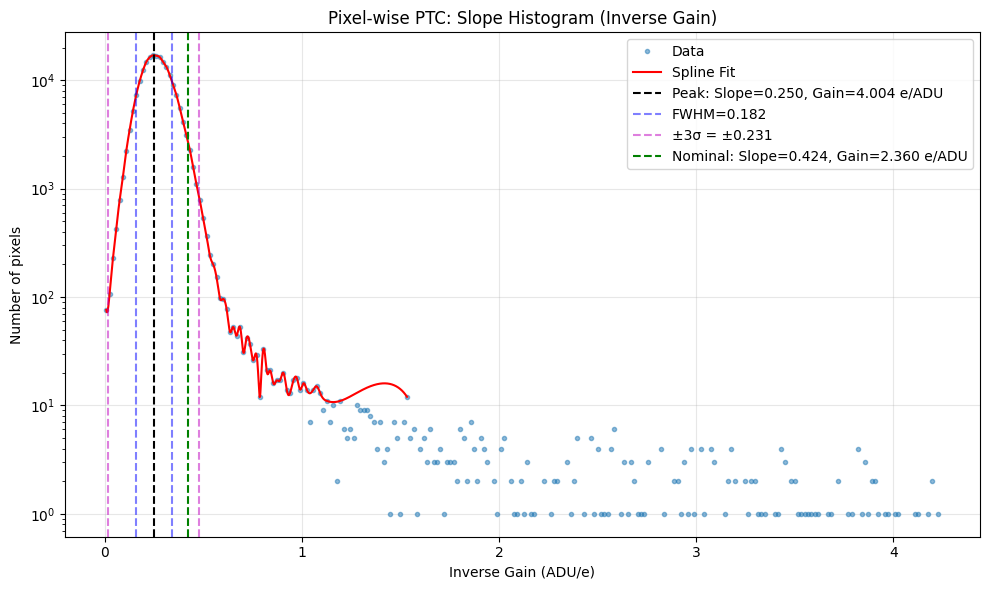

In [201]:
slope_image, intercept_image, gain_image, info = fit_photon_transfer_curve_masked(
    pixelwise_results_df,
    signal_min=3_000,
    signal_max=45_000,
    n_plot=10,
    n_clip_iters=3,
    clip_sigma=2.0,
    min_points_per_pixel=3,
    use_mad_sigma=False,
)


nominal_gain = 2.36  # e/ADU
fig_gain_hist = plot_gain_histogram(gain_image, nominal_gain=nominal_gain, hist_range=(0,10*nominal_gain), 
                                    nbins = 250, hist_fit_min_counts=10, spline_x_points=1000)
fig_slope_hist = plot_slope_histogram(slope_image, nominal_gain=nominal_gain, hist_range=(0,10/nominal_gain), 
                                      nbins = 250, hist_fit_min_counts=10, spline_x_points=1000)

Fitted Gain from Variance PTC: K = 3.511 e-/ADU


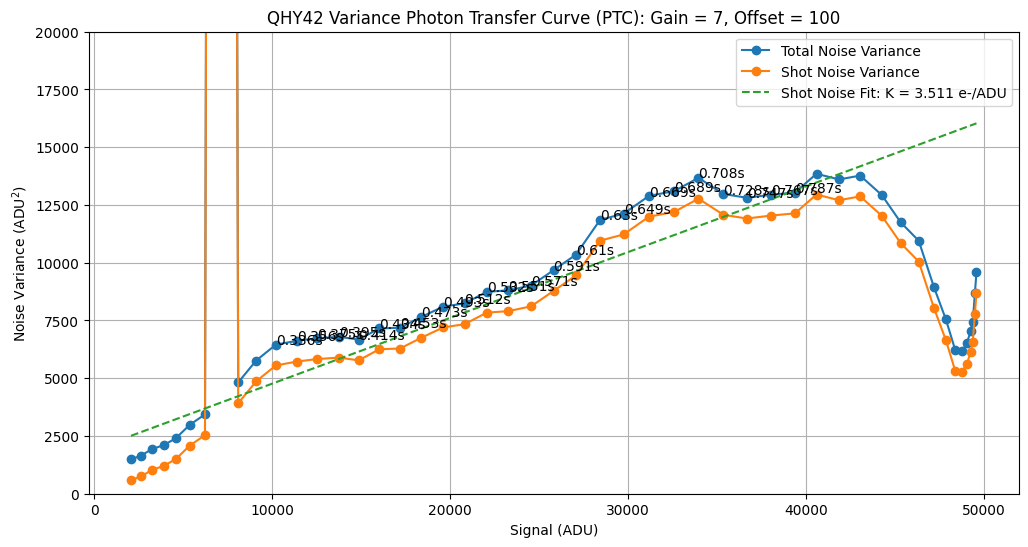

In [202]:
# variance PTC
# analyze the PTC
exposure_times = pixelwise_results_df["exposure_time"][:-1]
signal = pixelwise_results_df["mean"][:-1]
sigma_total = pixelwise_results_df["std"][:-1]
sigma_shot = np.sqrt(sigma_total**2 - read_noise**2)


fig, ax = plt.subplots(1,1, figsize=(12,6))
ax.plot(signal, sigma_total**2, 'o-', label = "Total Noise Variance")
ax.plot(signal, sigma_shot**2, 'o-', label = "Shot Noise Variance")

ax.grid(which='both')
# fit a line to the shot noise variance within the linear region
signal_linear_min = 10000  # ADU
signal_linear_max = 40000  # ADU

linear_region_mask = (signal >= signal_linear_min) & (signal <= signal_linear_max)
signal_linear = signal[linear_region_mask]
sigma_shot_linear = sigma_shot[linear_region_mask]

# fit a line to sigma_shot_linear^2 vs signal_linear
slope, intercept = np.polyfit(signal_linear, sigma_shot_linear**2, 1)

print(f"Fitted Gain from Variance PTC: K = {1/slope:.3f} e-/ADU")
ax.plot(signal, slope * signal + intercept, '--', label = "Shot Noise Fit: K = {:.3f} e-/ADU".format(1/slope))

# plot the exposure time on a second x-axis

ax.legend()

ax.set_xlabel("Signal (ADU)")
ax.set_ylabel("Noise Variance (ADU$^2$)")
ax.set_title("QHY42 Variance Photon Transfer Curve (PTC): Gain = 7, Offset = 100")
ax.set_ylim(0, 20000)
# label each point with its exposure time
for i, exptime in enumerate(exposure_times):
    if signal[i] >= signal_linear_min and signal[i] <= signal_linear_max:
        ax.text(signal[i], sigma_total[i]**2, f"{exptime}s")




In [203]:
exposure_times

0     0.140
1     0.160
2     0.179
3     0.199
4     0.218
5     0.238
6     0.258
7     0.277
8     0.297
9     0.316
10    0.336
11    0.356
12    0.375
13    0.395
14    0.414
15    0.434
16    0.453
17    0.473
18    0.493
19    0.512
20    0.532
21    0.551
22    0.571
23    0.591
24    0.610
25    0.630
26    0.649
27    0.669
28    0.689
29    0.708
30    0.728
31    0.747
32    0.767
33    0.787
34    0.806
35    0.826
36    0.845
37    0.865
38    0.884
39    0.904
40    0.924
41    0.943
42    0.963
43    0.982
44    1.002
45    1.022
46    1.041
47    1.061
48    1.080
Name: exposure_time, dtype: float64